<a href="https://colab.research.google.com/github/pach28/Predict-Podcast-Listening-Time/blob/main/NaN_Imputation_RF_y_Modelado_por_Combinacion_PPLT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

pt1

#instalamos librerias necesarias e iniciamos sesion de kaggle para acceder a la data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

sns.set_style('whitegrid')

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
!pip install dabl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.5/558.5 kB 15.1 MB/s eta 0:00:00


In [ ]:
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
import os

# Download the competition dataset
playground_series_s5e4_path = kagglehub.competition_download('playground-series-s5e4')
# Extract the directory name from the downloaded path
dataset_dir = os.path.splitext(playground_series_s5e4_path)[0]

# Construct the correct paths to the train.csv and test.csv files
train_csv_path = os.path.join(dataset_dir, 'train.csv')
test_csv_path = os.path.join(dataset_dir, 'test.csv')
sample_submission_csv_path = os.path.join(dataset_dir, 'sample_submission.csv')
# Read the CSV files using the correct paths
train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)
sample_submission_df = pd.read_csv(sample_submission_csv_path)

100%|██████████| 22.3M/22.3M [00:01<00:00, 18.6MB/s]

Extracting files...


In [ ]:
#datos extra
dataset_name = "ysthehurricane/podcast-listening-time-prediction-dataset"
extra = os.path.splitext(kagglehub.dataset_download(dataset_name))[0]
train_extra_path = os.path.join(extra, 'podcast_dataset.csv')
train_extra_df = pd.read_csv(train_extra_path)

In [ ]:
train_extra_df.head()

,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,Healthy Living,Episode 77,99.25,Health,21.37,Thursday,Night,70.22,3,Positive,55.158695
1,Mystery Matters,Episode 6,19.43,True Crime,47.19,Friday,Evening,75.15,1,Neutral,7.686559
2,Current Affairs,Episode 1,117.03,News,96.33,Sunday,Night,57.95,3,Neutral,110.064645
3,Mystery Matters,Episode 38,16.97,True Crime,25.73,Monday,Night,24.19,0,Positive,12.000380
4,Humor Hub,Episode 73,83.48,Comedy,76.69,Tuesday,Afternoon,42.31,3,Positive,NaN


In [ ]:
train_df.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


#EDA

In [ ]:
#quitamos el NaN de Number_of_Ads
train_df = train_df.dropna(subset=['Number_of_Ads'])

antes de tratar los outliers tratamos los NaN

In [ ]:
#buscamos un ejemplo especifico
#buscamos todos los datos de Mystery Matter y episode 98
train_df[(train_df['Podcast_Name'] == 'Mystery Matters') & (train_df['Episode_Title'] == 'Episode 98')]

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
13681,13681,Mystery Matters,Episode 98,43.91,True Crime,66.96,Saturday,Evening,NaN,2.0,Neutral,29.28240
13945,13945,Mystery Matters,Episode 98,116.74,True Crime,84.28,Tuesday,Morning,89.23,2.0,Negative,77.29858
16608,16608,Mystery Matters,Episode 98,40.28,True Crime,28.02,Tuesday,Night,NaN,0.0,Neutral,16.06603
19843,19843,Mystery Matters,Episode 98,78.38,True Crime,60.86,Tuesday,Evening,45.17,2.0,Negative,47.41398
...,...,...,...,...,...,...,...,...,...,...,...,...
739465,739465,Mystery Matters,Episode 98,30.51,True Crime,50.21,Saturday,Evening,70.73,0.0,Positive,22.04182
744404,744404,Mystery Matters,Episode 98,79.99,True Crime,56.74,Sunday,Night,80.44,0.0,Negative,69.00148
745272,745272,Mystery Matters,Episode 98,14.40,True Crime,83.20,Friday,Night,59.44,0.0,Positive,2.13361
747191,747191,Mystery Matters,Episode 98,7.26,True Crime,97.82,Tuesday,Night,17.88,0.0,Neutral,3.13557


para poder realizar el tratamiento de NaN necesitamos nuestras columnas codificadas en dummies

In [ ]:
# Realizar one-hot encoding en la columna 'Publication_Day'
train_df_copy = train_df.copy()
train_df_copy = pd.get_dummies(train_df_copy, columns=['Publication_Day'], prefix='PD', dtype=int)
train_df_copy = pd.get_dummies(train_df_copy, columns=['Publication_Time'], prefix='PT', dtype=int)
train_df_copy = pd.get_dummies(train_df_copy, columns=['Episode_Sentiment'], prefix='ES', dtype=int)
# Ver los cambios en el DataFrame
train_df_copy.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes,PD_Friday,...,PD_Thursday,PD_Tuesday,PD_Wednesday,PT_Afternoon,PT_Evening,PT_Morning,PT_Night,ES_Negative,ES_Neutral,ES_Positive
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,NaN,0.0,31.41998,0,...,1,0,0,0,0,0,1,0,0,1
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,75.95,2.0,88.01241,0,...,0,0,0,1,0,0,0,1,0,0
2,2,Study Sessions,Episode 16,73.90,Education,69.97,8.97,0.0,44.92531,0,...,0,1,0,0,1,0,0,1,0,0
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,78.70,2.0,46.27824,0,...,0,0,0,0,0,1,0,0,0,1
4,4,Mind & Body,Episode 86,110.51,Health,80.07,58.68,3.0,75.61031,0,...,0,0,0,1,0,0,0,0,1,0


In [ ]:
#one-hot en test_df
test_df_copy = test_df.copy()
test_df_copy = pd.get_dummies(test_df_copy, columns=['Publication_Day'], prefix='PD', dtype=int)
test_df_copy = pd.get_dummies(test_df_copy, columns=['Publication_Time'], prefix='PT', dtype=int)
test_df_copy = pd.get_dummies(test_df_copy, columns=['Episode_Sentiment'], prefix='ES', dtype=int)
#
test_df_copy.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,PD_Friday,PD_Monday,...,PD_Thursday,PD_Tuesday,PD_Wednesday,PT_Afternoon,PT_Evening,PT_Morning,PT_Night,ES_Negative,ES_Neutral,ES_Positive
0,750000,Educational Nuggets,Episode 73,78.96,Education,38.11,53.33,1.0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,750001,Sound Waves,Episode 23,27.87,Music,71.29,NaN,0.0,0,0,...,0,0,0,0,0,1,0,0,1,0
2,750002,Joke Junction,Episode 11,69.10,Comedy,67.89,97.51,0.0,1,0,...,0,0,0,0,1,0,0,0,0,1
3,750003,Comedy Corner,Episode 73,115.39,Comedy,23.40,51.75,2.0,0,0,...,0,0,0,0,0,1,0,0,0,1
4,750004,Life Lessons,Episode 50,72.32,Lifestyle,58.10,11.30,2.0,0,0,...,0,0,1,0,0,1,0,0,1,0


In [ ]:
train_df_copy.columns

Index(['id', 'Podcast_Name', 'Episode_Title', 'Episode_Length_minutes',
       'Genre', 'Host_Popularity_percentage', 'Guest_Popularity_percentage',
       'Number_of_Ads', 'Listening_Time_minutes', 'PD_Friday', 'PD_Monday',
       'PD_Saturday', 'PD_Sunday', 'PD_Thursday', 'PD_Tuesday', 'PD_Wednesday',
       'PT_Afternoon', 'PT_Evening', 'PT_Morning', 'PT_Night', 'ES_Negative',
       'ES_Neutral', 'ES_Positive'],
      dtype='object')

In [ ]:
test_df_copy.columns

Index(['id', 'Podcast_Name', 'Episode_Title', 'Episode_Length_minutes',
       'Genre', 'Host_Popularity_percentage', 'Guest_Popularity_percentage',
       'Number_of_Ads', 'PD_Friday', 'PD_Monday', 'PD_Saturday', 'PD_Sunday',
       'PD_Thursday', 'PD_Tuesday', 'PD_Wednesday', 'PT_Afternoon',
       'PT_Evening', 'PT_Morning', 'PT_Night', 'ES_Negative', 'ES_Neutral',
       'ES_Positive'],
      dtype='object')

In [ ]:
#cuantas combinaciones unicas de Podcast_name y Episode_Title hay
combinaciones = train_df.groupby(['Podcast_Name', 'Episode_Title']).size().reset_index(name='count')

In [ ]:
#utilizar rf para rellenar los nan de episode_length_minutes
for index, row in combinaciones.iterrows():
  name = row['Podcast_Name']
  title = row['Episode_Title']
  data_train_not_nan = train_df_copy[(train_df_copy['Podcast_Name'] == name) & (train_df_copy['Episode_Title'] == title) & (train_df_copy['Episode_Length_minutes'].notnull())]
  data_train_nan = train_df_copy[(train_df_copy['Podcast_Name'] == name) & (train_df_copy['Episode_Title'] == title) & (train_df_copy['Episode_Length_minutes'].isnull())]
  data_test_nan = test_df_copy[(test_df_copy['Podcast_Name'] == name) & (test_df_copy['Episode_Title'] == title) & (test_df_copy['Episode_Length_minutes'].isnull())]
  ratio_listen_time = data_train_not_nan['Listening_Time_minutes'].sum() / data_train_not_nan['Episode_Length_minutes'].sum()
  mean_length = data_train_not_nan['Episode_Length_minutes'].mean()
  data_train_nan['Episode_Length_minutes'] = data_train_nan['Listening_Time_minutes'] / ratio_listen_time
  data_test_nan['Episode_Length_minutes'] = mean_length
  train_df_copy.update(data_train_nan)
  test_df_copy.update(data_test_nan)

Target looks like regression


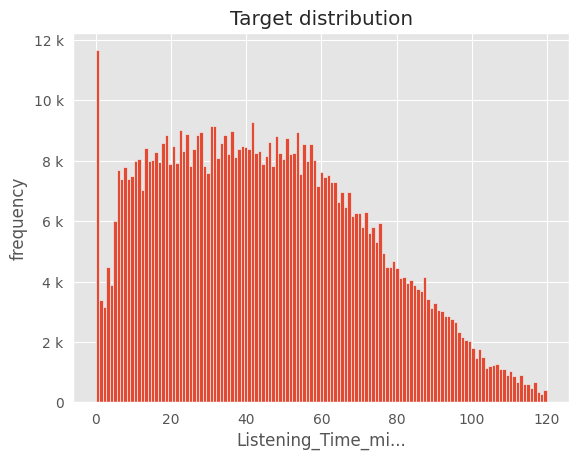

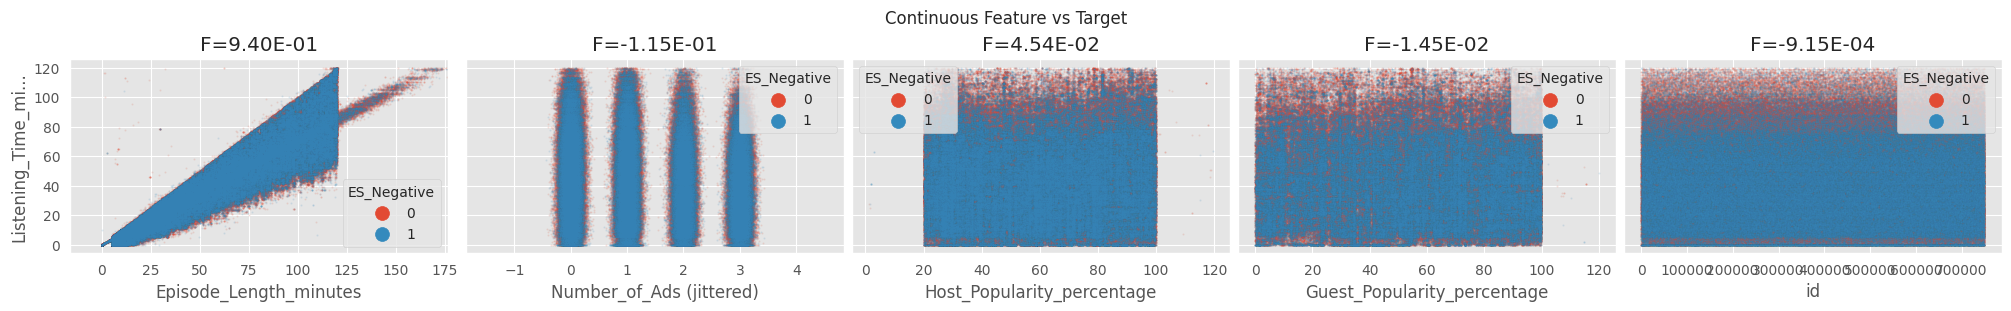

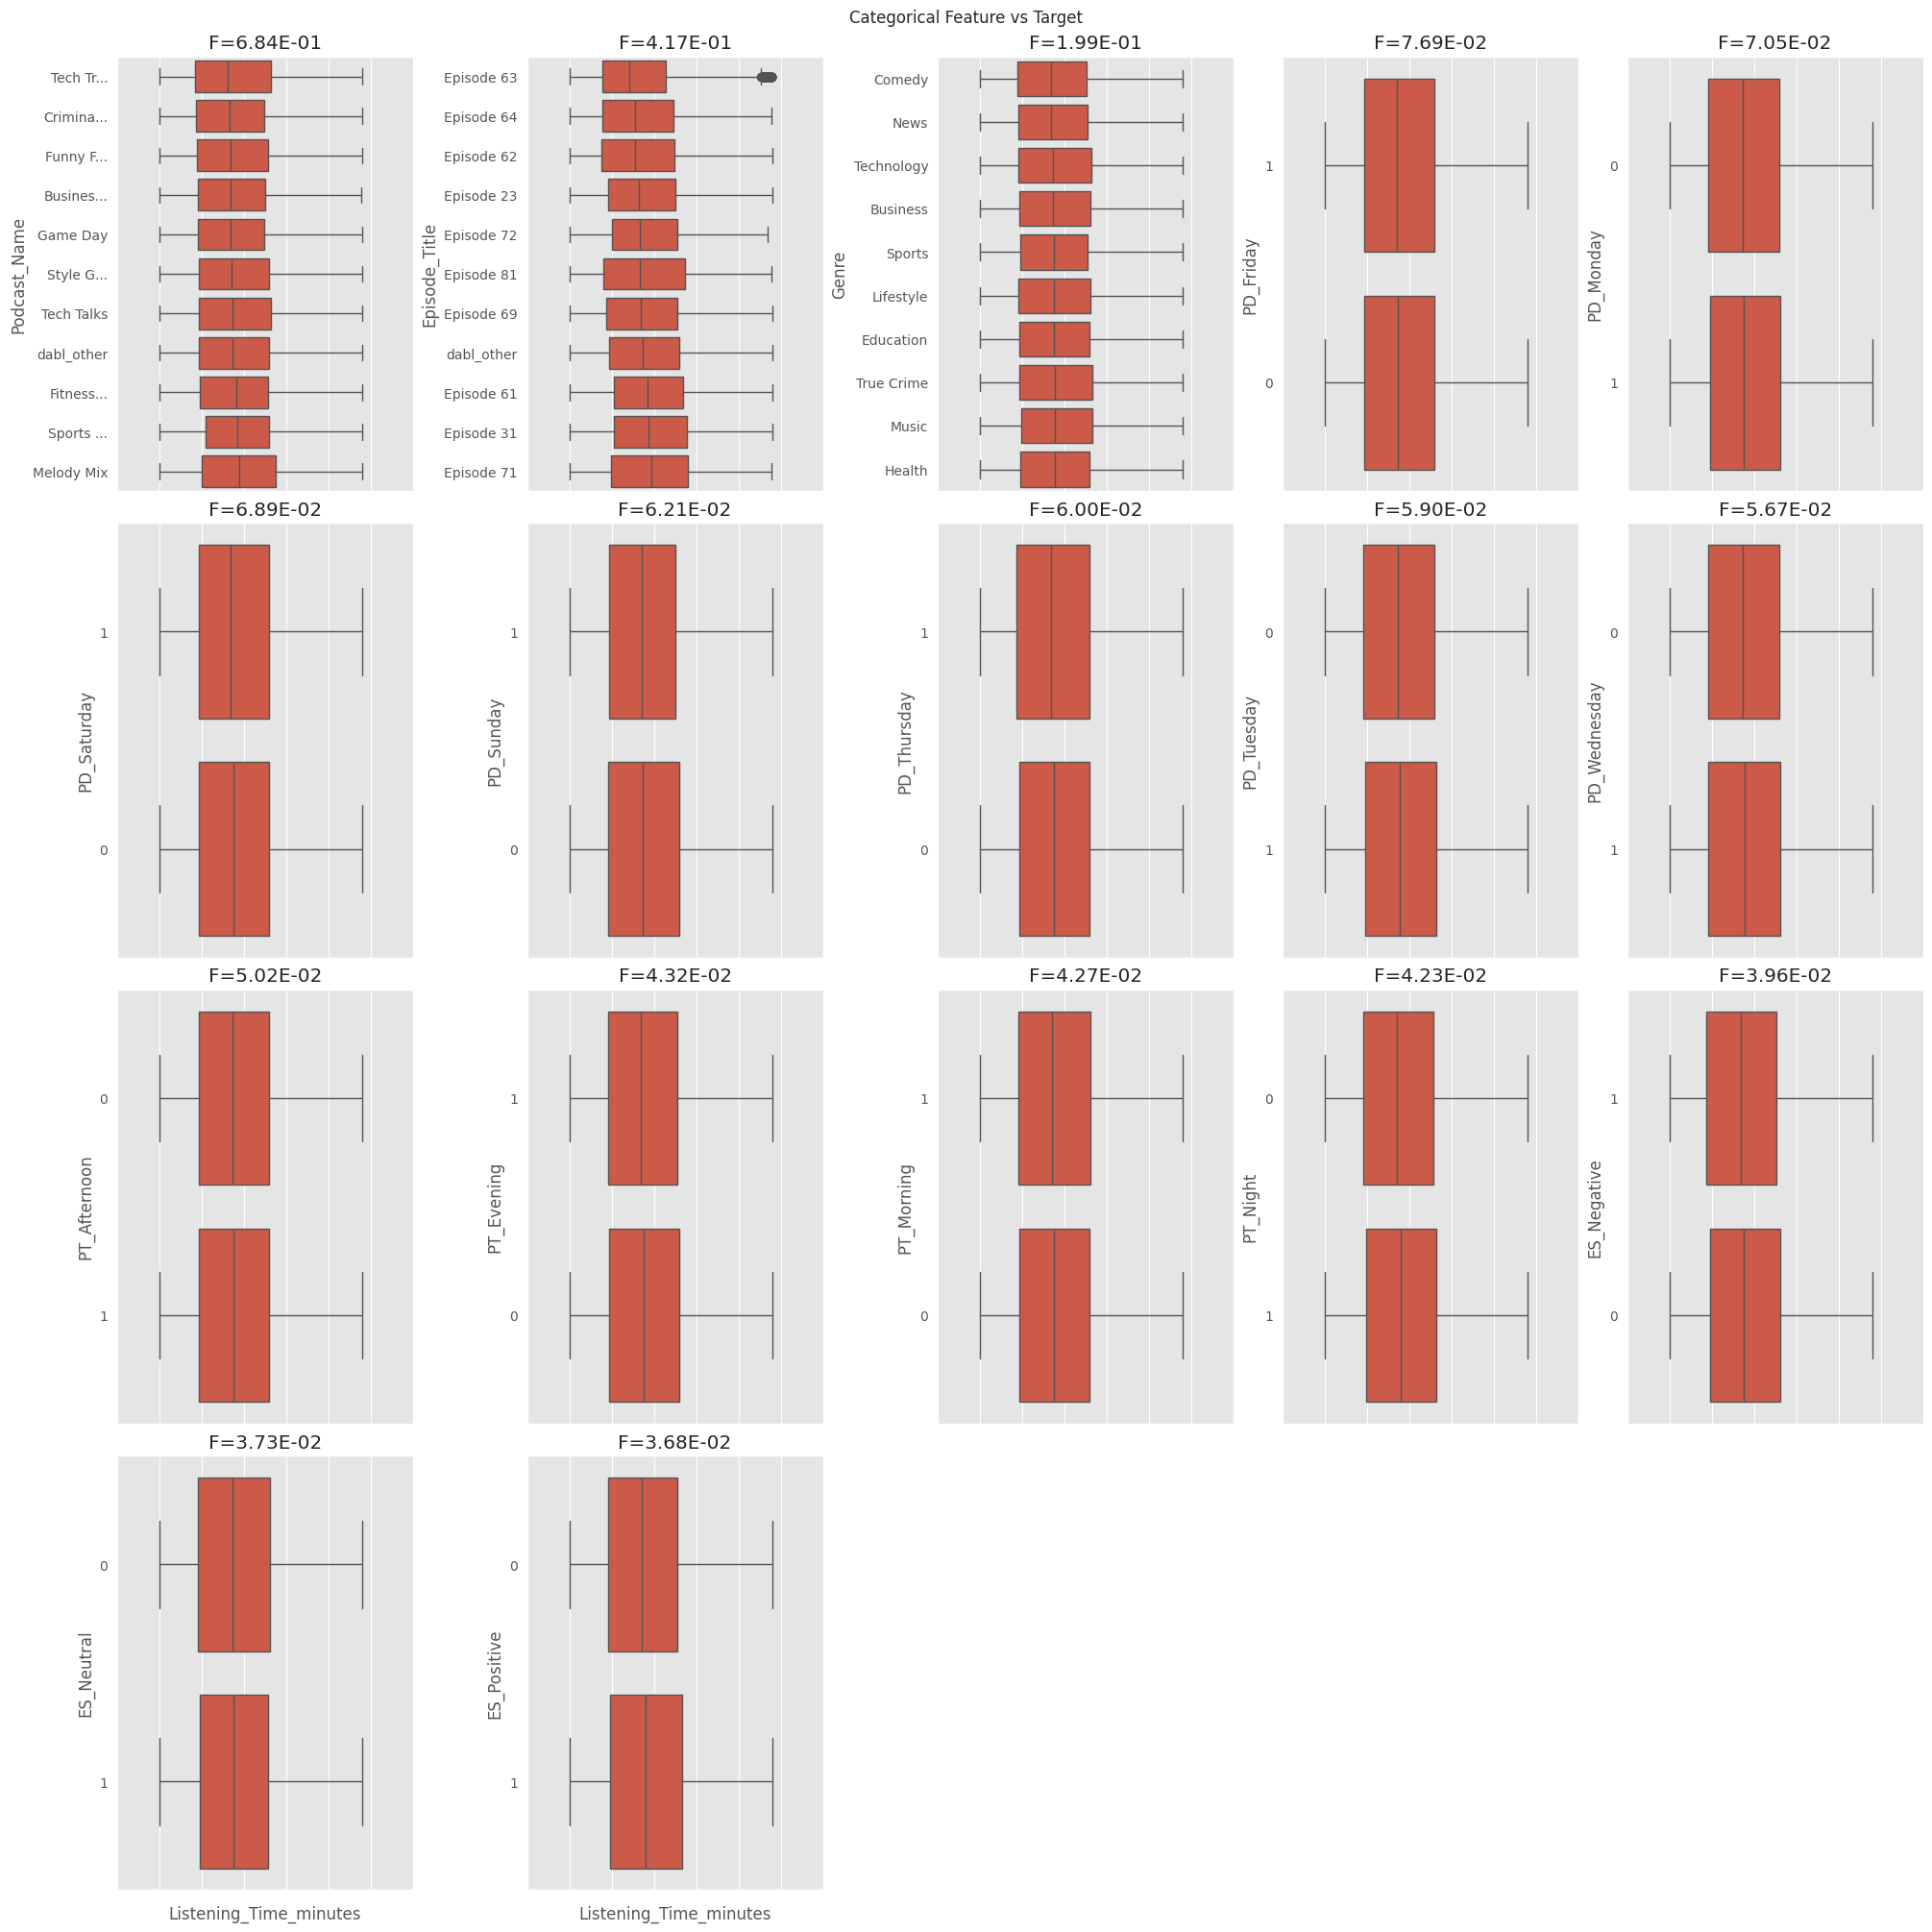

In [ ]:
import dabl
plt.style.use('ggplot')
warnings.filterwarnings('ignore')
dabl.plot(train_df_copy, target_col = 'Listening_Time_minutes')
# Acceder a la figura y los ejes
fig, ax = plt.gcf(), plt.gca()

# Eliminar la cuadrícula
ax.grid(False)

# Mostrar el gráfico
plt.show()

In [ ]:
#Episode_Length_minutes > 0
#Episode_Length_minutes > Listening_Time_miutes
#Host_Popularity_percentage < 100
#Number_of_Ads < 12
train_df_copy_2 = train_df_copy
train_df_copy_2 = train_df_copy_2[train_df_copy_2['Episode_Length_minutes'] > 0]
train_df_copy_2 = train_df_copy_2[train_df_copy_2['Episode_Length_minutes'] > train_df_copy_2['Listening_Time_minutes']]
train_df_copy_2 = train_df_copy_2[train_df_copy_2['Host_Popularity_percentage'] < 100]
train_df_copy_2 = train_df_copy_2[train_df_copy_2['Number_of_Ads'] < 12]

In [ ]:
#todo dato por arriba los 120 en length se vuelva 120
train_df_copy_2['Episode_Length_minutes'] = train_df_copy_2['Episode_Length_minutes'].apply(lambda x: 120 if x > 120 else x)

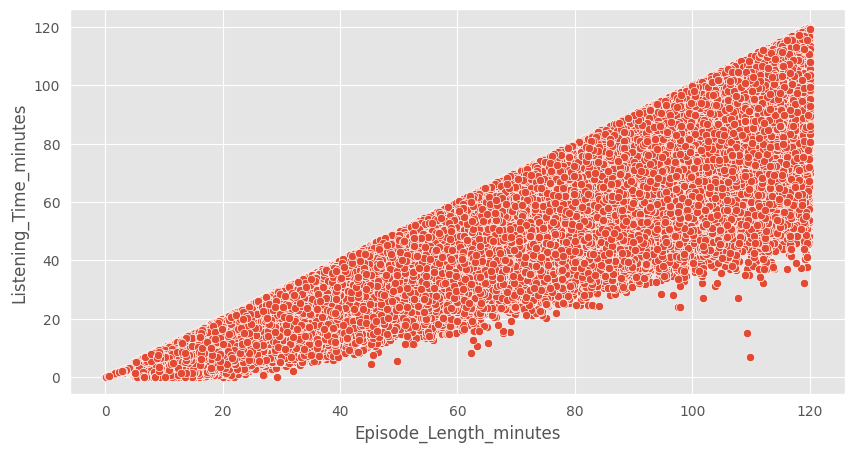

In [ ]:
#scatterplot length y listening
plt.figure(figsize=(10,5))
sns.scatterplot(x='Episode_Length_minutes', y='Listening_Time_minutes', data=train_df_copy_2)
plt.show()

In [ ]:
def tratar_nan_con_dummy(df, columna_nan):

    # Crear la columna dummy 'NA_columna_nan'
    df[f'NA_{columna_nan}'] = np.where(df[columna_nan].isnull(), 1, 0)

    # Asignar 0 a los valores NaN en la columna original
    df[columna_nan] = df[columna_nan].fillna(0)

    return df

In [ ]:
train_df_copy_3 = tratar_nan_con_dummy(train_df_copy_2, 'Guest_Popularity_percentage')

In [ ]:
#todo dato por arriba de 100 en popularity se vuelva 100
train_df_copy_3['Guest_Popularity_percentage'] = train_df_copy_3['Guest_Popularity_percentage'].apply(lambda x: 100 if x > 100 else x)

In [ ]:
#todo dato por arriba de 100 en popularity host se vuelva 100
train_df_copy_3['Host_Popularity_percentage'] = train_df_copy_3['Host_Popularity_percentage'].apply(lambda x: 100 if x > 100 else x)

In [ ]:
test_df_copy_2 = tratar_nan_con_dummy(test_df_copy, 'Guest_Popularity_percentage')

In [ ]:
#world watch episode 99 de train
train_df_copy_3[(train_df_copy_3['Podcast_Name'] == 'World Watch') & (train_df_copy_3['Episode_Title'] == 'Episode 99')]['Episode_Length_minutes'].mean()

np.float64(65.84228730117157)

In [ ]:
#donde esta el id 999999 en test, su index
test_df_copy_2[test_df_copy_2['Episode_Length_minutes'] == test_df_copy_2['Episode_Length_minutes'].max()].index

Index([54434], dtype='int64')

In [ ]:
test_df_copy_2.at[54434, 'Episode_Length_minutes'] = 65.84

In [ ]:
test_df_copy_2[test_df_copy_2['Episode_Length_minutes'] == test_df_copy_2['Episode_Length_minutes'].max()]['Episode_Length_minutes']

,Episode_Length_minutes
180050,120.73


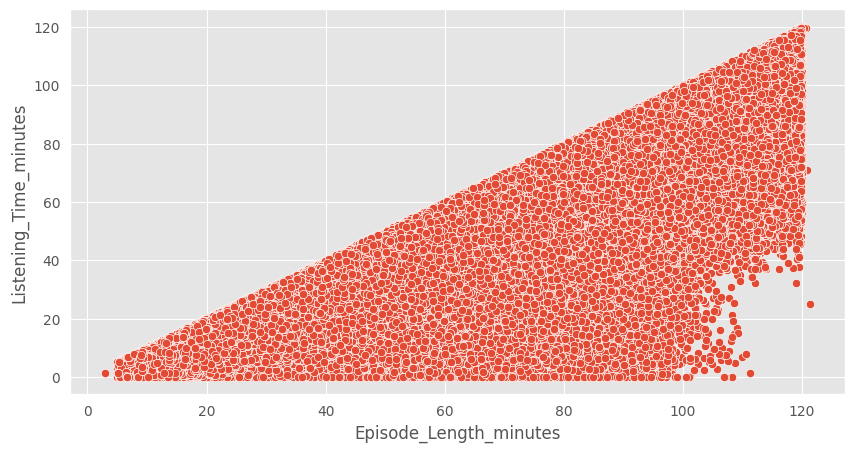

In [ ]:
#scatterplot liestening y episode length
plt.figure(figsize=(10,5))
sns.scatterplot(x='Episode_Length_minutes', y='Listening_Time_minutes', data=train_df_copy_3)
plt.show()

In [ ]:
#proporcion de tiempo escuchado
train_df_copy_3['Listening_Time_minutes'].sum() / train_df_copy_3['Episode_Length_minutes'].sum()

np.float64(0.7093930318953247)

In [ ]:
import xgboost as xgb
# Modelos de regresión lineal
from sklearn.linear_model import LinearRegression

# Modelos basados en árboles
from sklearn.ensemble import RandomForestRegressor

# Modelos Gradient Boosting
import lightgbm as lgb
# Funciones de evaluación
from sklearn.metrics import mean_squared_error, r2_score

# Funciones de preprocesamiento de datos
from sklearn.model_selection import train_test_split

In [ ]:
X = train_df_copy_3.drop(['Podcast_Name', 'Episode_Title','id','Genre','Listening_Time_minutes'], axis=1)
y = train_df_copy_3['Listening_Time_minutes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=28)

In [ ]:
#vamos a guardar los valores de mse y r2 de los 4800 modelos
mse_values_lgbm = []
r2_values_lgbm = []
mse_values_rf = []
r2_values_rf = []
mse_values_lr = []
r2_values_lr = []

In [ ]:
for index, row in combinaciones.iterrows():
  name = row['Podcast_Name']
  title = row['Episode_Title']
  X = train_df_copy_3[(train_df_copy_3['Podcast_Name'] == name) & (train_df_copy_3['Episode_Title'] == title)]
  y = X['Listening_Time_minutes']
  X = X.drop(['Podcast_Name', 'Episode_Title','id','Genre','Listening_Time_minutes'], axis=1)
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=28)
  #lgbm
  modelgbm = xgb.XGBRegressor()
  modelgbm.fit(X_train, y_train)
  y_pred = modelgbm.predict(X_test)
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  mse_values_lgbm.append(mse)
  r2_values_lgbm.append(r2)
  #random forest
  modelrf = RandomForestRegressor()
  modelrf.fit(X_train, y_train)
  y_pred = modelrf.predict(X_test)
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  mse_values_rf.append(mse)
  r2_values_rf.append(r2)
  #linear
  model = LinearRegression()
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  mse_values_lr.append(mse)
  r2_values_lr.append(r2)

In [ ]:
print(len(mse_values_lgbm))
print(len(mse_values_rf))
print(len(mse_values_lr))

4800
4800
4800


In [ ]:
#hacer un df con los mse y r2 values de los 3 modelos
df_mse_r2 = pd.DataFrame({'mse_lgbm': mse_values_lgbm, 'r2_lgbm': r2_values_lgbm, 'mse_rf': mse_values_rf, 'r2_rf': r2_values_rf, 'mse_lr': mse_values_lr, 'r2_lr': r2_values_lr})
df_mse_r2.head()

,mse_lgbm,r2_lgbm,mse_rf,r2_rf,mse_lr,r2_lr
0,107.755855,0.812054,82.529605,0.856053,122.431625,0.786456
1,153.732621,0.795173,128.910254,0.828245,106.385475,0.858256
2,128.540491,0.866997,89.312506,0.907587,85.753817,0.911269
3,58.060520,0.869652,40.008399,0.910180,73.440365,0.835124
4,132.613185,0.776024,110.890186,0.812713,105.569850,0.821699


In [ ]:
df_mse_r2_2 = df_mse_r2.copy()
df_mse_r2_2['mse_min'] = df_mse_r2[['mse_lgbm', 'mse_rf', 'mse_lr']].min(axis=1)

In [ ]:
#hacemos una columna que diga lgbm o rf o lr dependiendo el minimo por fila
df_mse_r2_2['model_min'] = df_mse_r2_2[['mse_lgbm', 'mse_rf', 'mse_lr']].idxmin(axis=1)

In [ ]:
df_mse_r2_2.describe()

,mse_lgbm,r2_lgbm,mse_rf,r2_rf,mse_lr,r2_lr,mse_min
count,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000,4800.000000
mean,138.485091,0.792392,114.904156,0.827530,117.448293,0.823048,103.562793
std,53.647405,0.090220,42.013551,0.073734,38.724478,0.073578,35.193531
min,31.068469,-0.055654,23.985134,-0.109003,28.100680,-0.243991,23.985134
25%,100.597077,0.748943,85.831799,0.793503,90.017659,0.790859,78.990586
50%,130.342923,0.808942,108.991830,0.839993,112.583880,0.835682,99.358758
75%,167.348935,0.854343,137.746248,0.876504,138.599791,0.870691,124.193975
max,506.994937,0.968223,383.105938,0.971564,379.906994,0.970097,320.781102


In [ ]:
#en donde la columna model_min es mse_rf,...
index_rf = df_mse_r2_2[df_mse_r2_2['model_min'] == 'mse_rf'].index
index_lgbm = df_mse_r2_2[df_mse_r2_2['model_min'] == 'mse_lgbm'].index
index_lr = df_mse_r2_2[df_mse_r2_2['model_min'] == 'mse_lr'].index

In [ ]:
test_df_copy_2['Listening_Time_minutes'] = 0

In [ ]:
#guardar en csv test_df_copy y train_df_copy_3
test_df_copy_2.to_csv('test_df_copy.csv', index=False)
train_df_copy_3.to_csv('train_df_copy_3.csv', index=False)

In [ ]:
#ya tenemos el index de donde van a iterar los diferentes modelos ahora para test
for i in index_rf:
  name = combinaciones.loc[i, 'Podcast_Name']
  title = combinaciones.loc[i, 'Episode_Title']
  xtest = test_df_copy_2[(test_df_copy_2['Podcast_Name'] == name) & (test_df_copy_2['Episode_Title'] == title)]
  xtest_model = xtest.drop(['Podcast_Name', 'Episode_Title','id','Genre','Listening_Time_minutes'],axis=1)
  xtrain = train_df_copy_3[(train_df_copy_3['Podcast_Name'] == name) & (train_df_copy_3['Episode_Title'] == title)]
  xtrain_model = xtrain.drop(['Podcast_Name', 'Episode_Title','id','Genre','Listening_Time_minutes'],axis=1)
  ytrain = xtrain['Listening_Time_minutes']
  modelrf = RandomForestRegressor()
  modelrf.fit(xtrain_model, ytrain)
  y_pred = modelrf.predict(xtest_model)
  #rellenar las predicciones en test_copy
  xtest['Listening_Time_minutes'] = y_pred
  test_df_copy_2.update(xtest)
for i in index_lgbm:
  name = combinaciones.loc[i, 'Podcast_Name']
  title = combinaciones.loc[i, 'Episode_Title']
  xtest = test_df_copy_2[(test_df_copy_2['Podcast_Name'] == name) & (test_df_copy_2['Episode_Title'] == title)]
  xtest_model = xtest.drop(['Podcast_Name', 'Episode_Title','id','Genre','Listening_Time_minutes'],axis=1)
  xtrain = train_df_copy_3[(train_df_copy_3['Podcast_Name'] == name) & (train_df_copy_3['Episode_Title'] == title)]
  xtrain_model = xtrain.drop(['Podcast_Name', 'Episode_Title','id','Genre','Listening_Time_minutes'],axis=1)
  ytrain = xtrain['Listening_Time_minutes']
  modelgbm = xgb.XGBRegressor()
  modelgbm.fit(xtrain_model, ytrain)
  y_pred = modelgbm.predict(xtest_model)
  #rellenar las predicciones en test_copy
  xtest['Listening_Time_minutes'] = y_pred
  test_df_copy_2.update(xtest)
for i in index_lr:
  name = combinaciones.loc[i, 'Podcast_Name']
  title = combinaciones.loc[i, 'Episode_Title']
  xtest = test_df_copy_2[(test_df_copy_2['Podcast_Name'] == name) & (test_df_copy_2['Episode_Title'] == title)]
  xtest_model = xtest.drop(['Podcast_Name', 'Episode_Title','id','Genre','Listening_Time_minutes'],axis=1)
  xtrain = train_df_copy_3[(train_df_copy_3['Podcast_Name'] == name) & (train_df_copy_3['Episode_Title'] == title)]
  xtrain_model = xtrain.drop(['Podcast_Name', 'Episode_Title','id','Genre','Listening_Time_minutes'],axis=1)
  ytrain = xtrain['Listening_Time_minutes']
  model = LinearRegression()
  model.fit(xtrain_model, ytrain)
  y_pred = model.predict(xtest_model)
  #rellenar las predicciones en test_copy
  xtest['Listening_Time_minutes'] = y_pred
  test_df_copy_2.update(xtest)

In [ ]:
train_df_copy_3['Listening_Time_minutes'].mean()

np.float64(45.50485533128788)

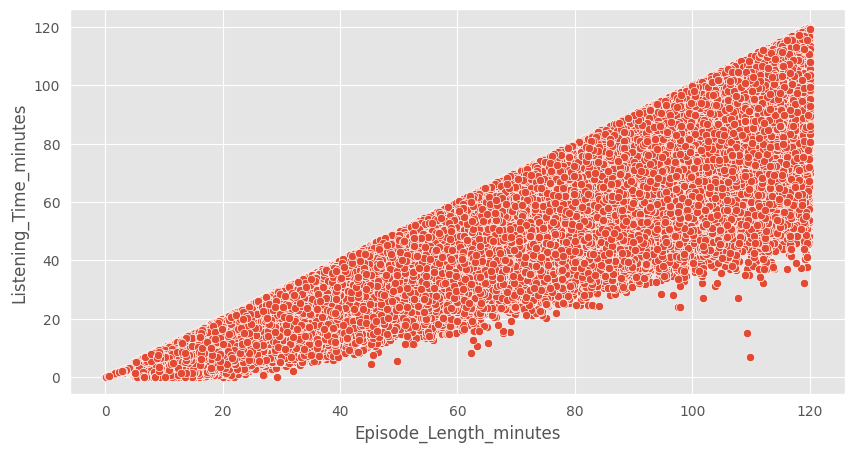

In [ ]:
#scatterplot listening vs length
plt.figure(figsize=(10,5))
sns.scatterplot(x='Episode_Length_minutes', y='Listening_Time_minutes', data=train_df_copy_3)
plt.show()

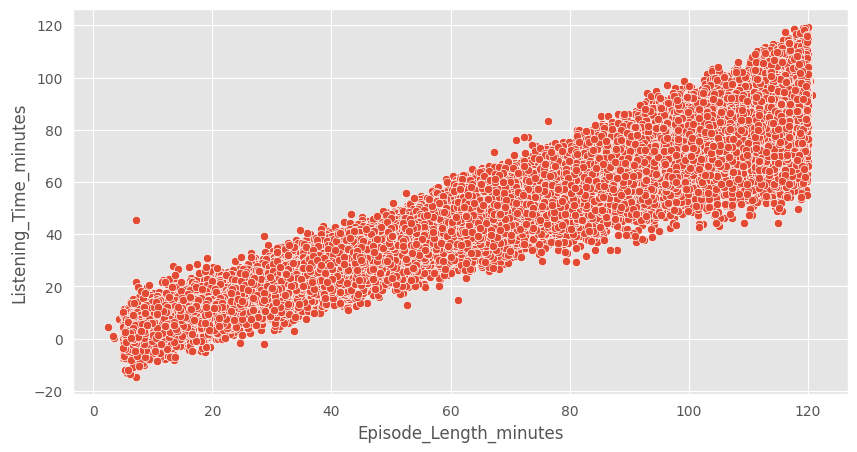

In [ ]:
#scatterplot listening vs length test
plt.figure(figsize=(10,5))
sns.scatterplot(x='Episode_Length_minutes', y='Listening_Time_minutes', data=test_df_copy_2)
plt.show()

In [ ]:
test_df_copy_2['Listening_Time_minutes'].min()

-3752.942614108681

In [ ]:
#index del min listening en test_df_copy_2
test_df_copy_2[test_df_copy_2['Listening_Time_minutes'] == test_df_copy_2['Listening_Time_minutes'].min()].index


Index([178393], dtype='int64')

In [ ]:
#cambiar el index 178393 por 45.5
test_df_copy_2.at[178393, 'Listening_Time_minutes'] = 45.5

In [ ]:
sample_submission_df['Listening_Time_minutes'] = test_df_copy_2['Listening_Time_minutes']

In [ ]:
#todo lo menor a 0 se hace 0 en listening time
sample_submission_df['Listening_Time_minutes'] = sample_submission_df['Listening_Time_minutes'].apply(lambda x: 0 if x < 0 else x)


In [ ]:
sample_submission_df.describe()

,id,Listening_Time_minutes
count,250000.000000,250000.000000
mean,874999.500000,45.786329
std,72168.927986,23.967144
min,750000.000000,0.000000
25%,812499.750000,26.684782
50%,874999.500000,45.491404
75%,937499.250000,64.377093
max,999999.000000,119.364769


In [ ]:
sample_submission_df.to_csv('submission_8.csv', index=False)

Target looks like regression


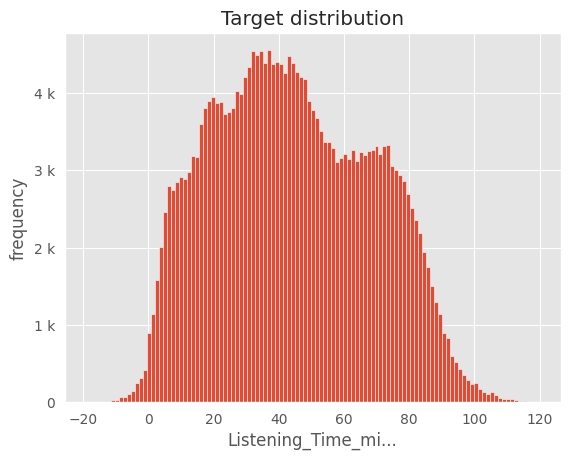

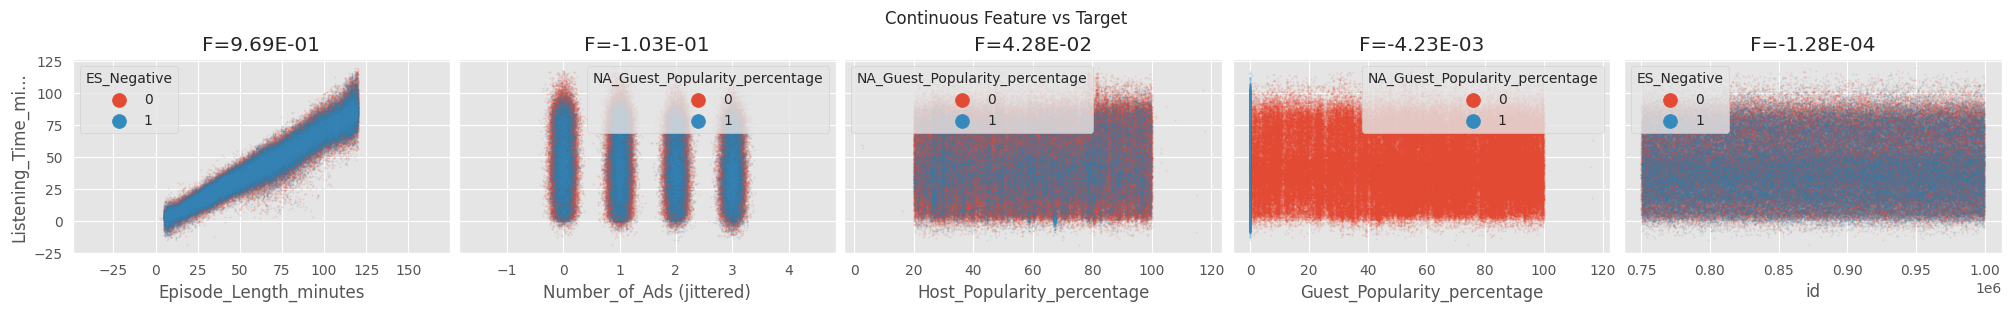

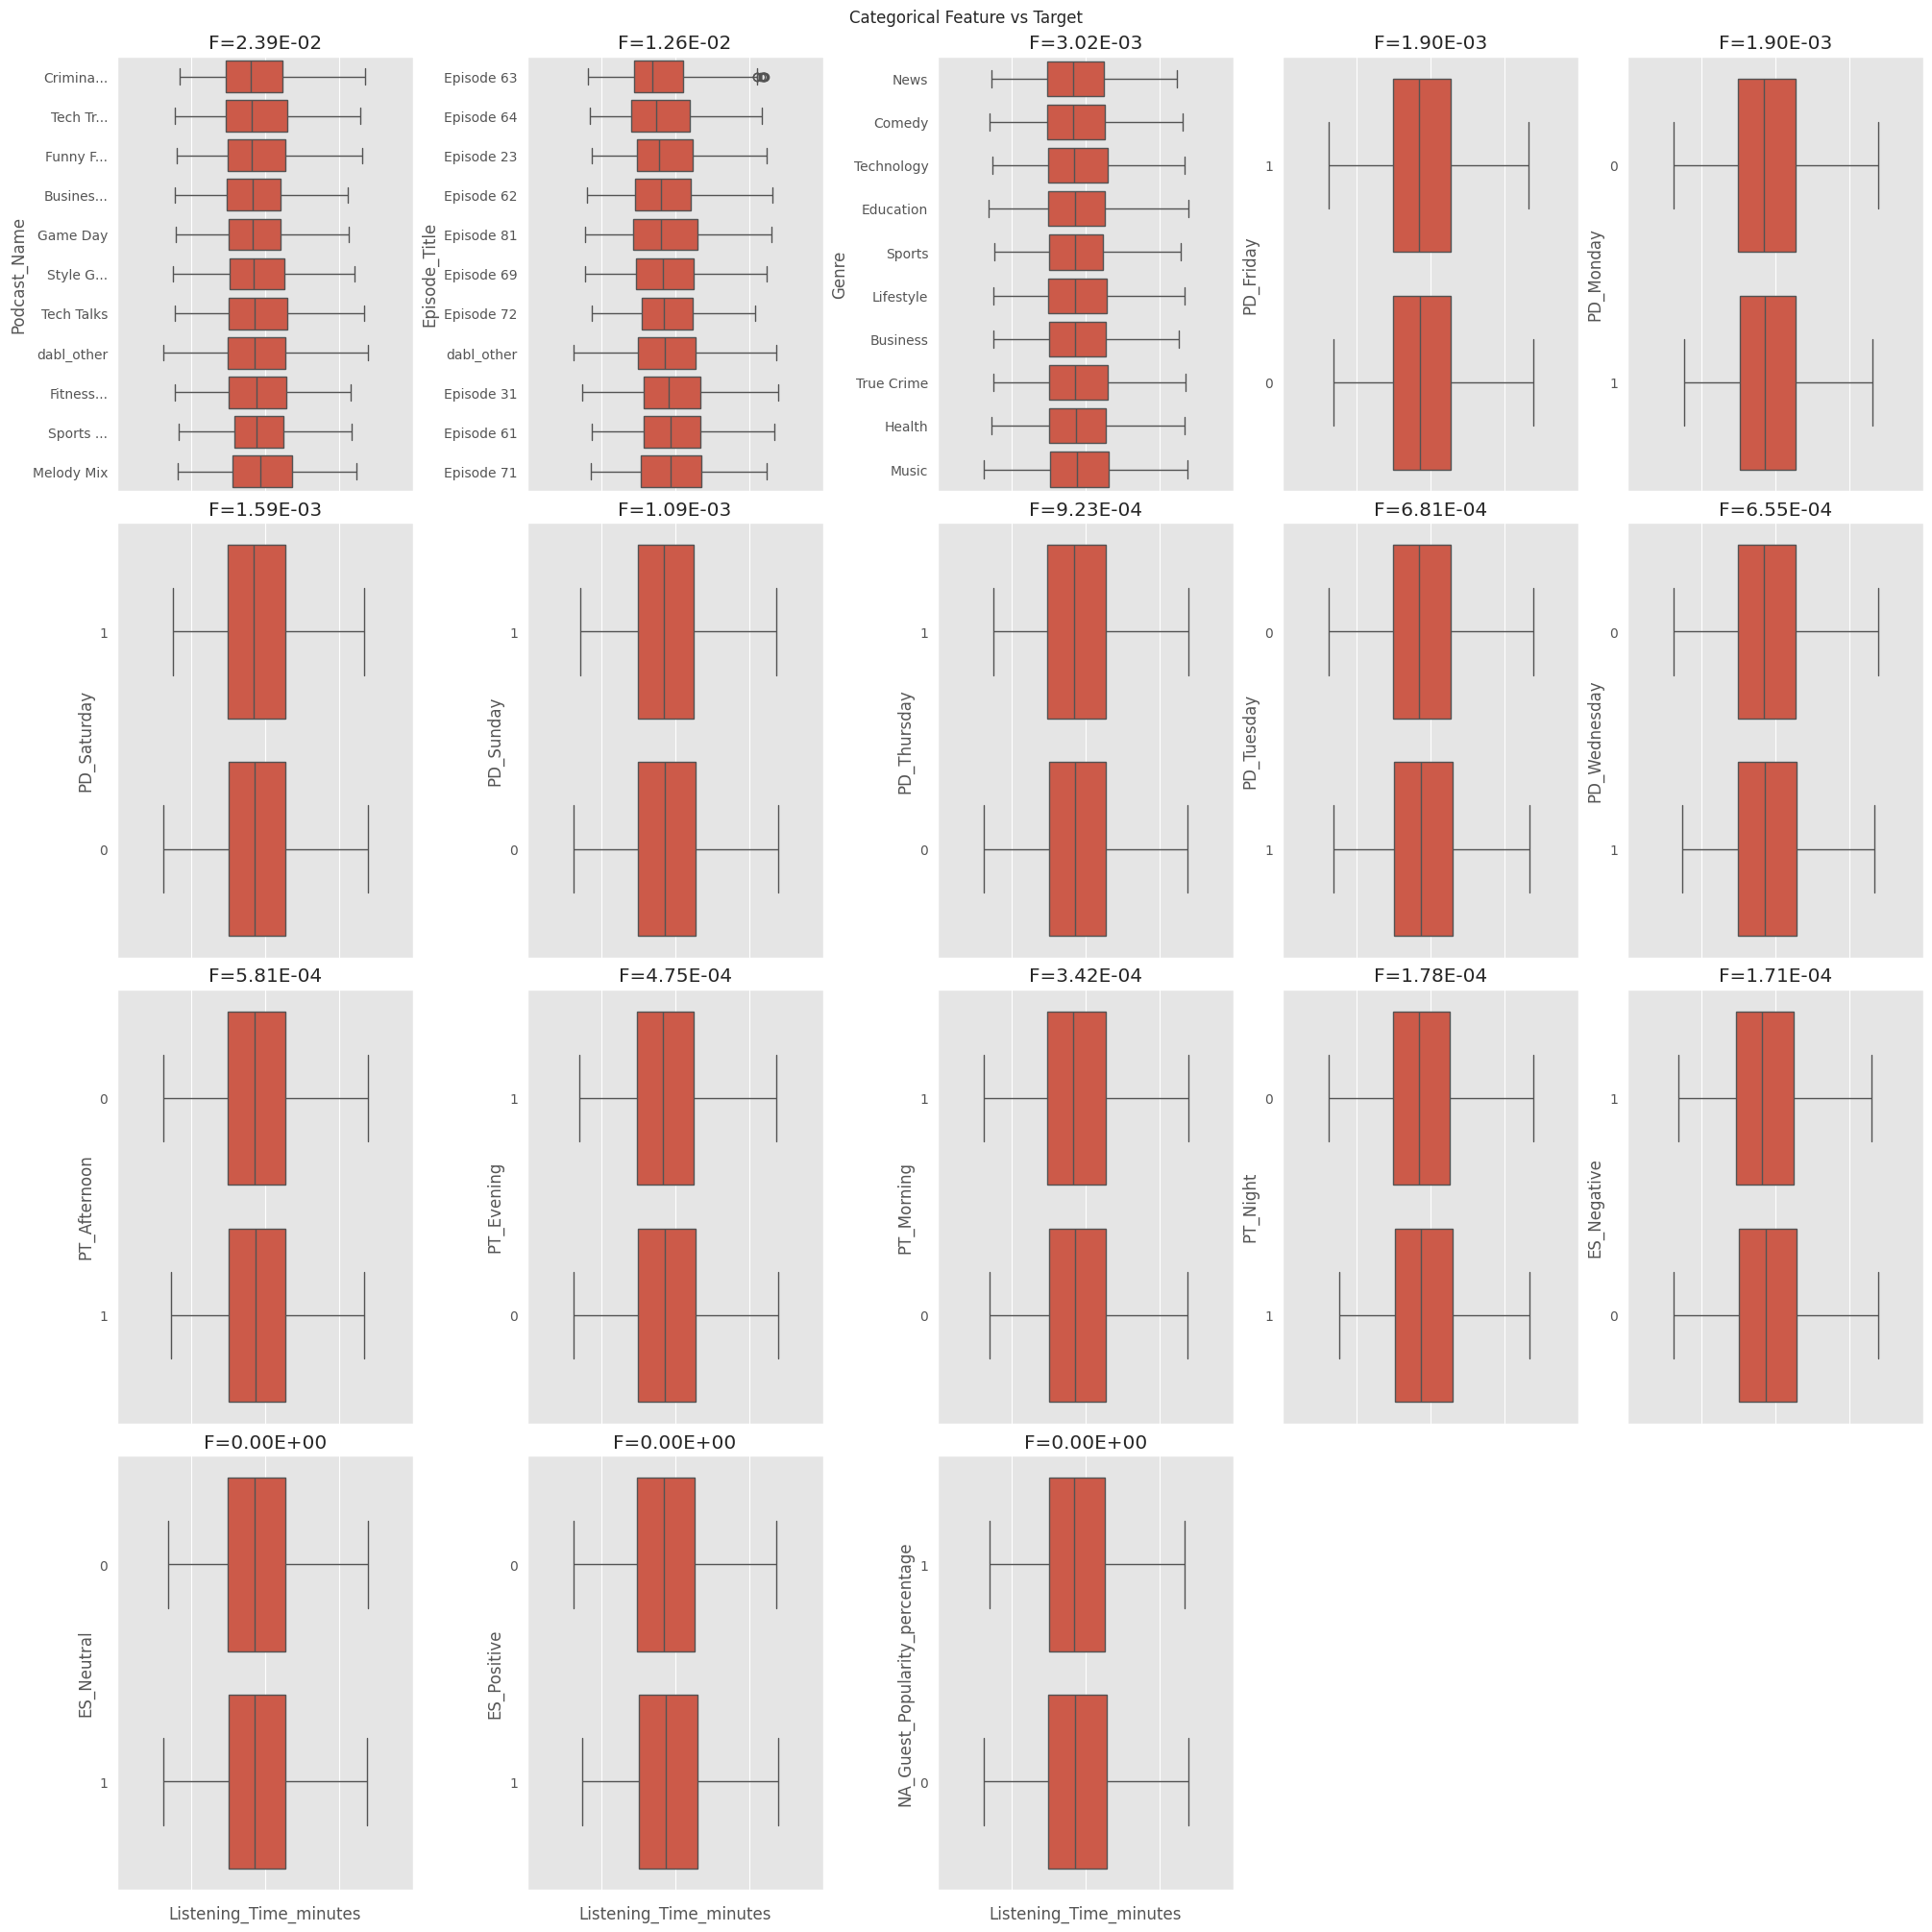

In [ ]:
plt.style.use('ggplot')
warnings.filterwarnings('ignore')
dabl.plot(test_df_copy, target_col = 'Listening_Time_minutes')
# Acceder a la figura y los ejes
fig, ax = plt.gcf(), plt.gca()

# Eliminar la cuadrícula
ax.grid(False)

# Mostrar el gráfico
plt.show()

In [ ]:
#seguimos analizando los patrones de train_df para observar patrones por titulo de programa

In [ ]:
names = train_df['Podcast_Name'].unique()